In [1]:
import pathlib
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from neighborly.ecs import Component, Active
from neighborly.components.stats import StatComponent, StatModifierType
from neighborly.factories.stats import StatComponentFactory
from neighborly.config import SimulationConfig
from neighborly.plugins import default_content
from neighborly.simulation import Simulation
from neighborly.loaders import load_characters
from neighborly.helpers.shared import add_modifier
from neighborly.plugins.modifiers import StatModifier

In [2]:
class StoryCreditScore(StatComponent):
    """Track a score for how interesting a character might be."""

    __stat_name__ = "StoryCreditScore"

    def __init__(
        self,
        base_value: float = 0,
    ) -> None:
        super().__init__(base_value, None, True)

class StoryCreditScoreFactory(StatComponentFactory):
    """Creates instances of WantForMarriage Components."""

    __component__ = "StoryCreditScore"

    def __init__(self) -> None:
        super().__init__(StoryCreditScore)

In [3]:
def on_recently_married(event):
    add_modifier(
        event.data["performer"],
        StatModifier(
            stat="StoryCreditScore",
            value=5,
            modifier_type=StatModifierType.FLAT,
            duration=5,
            reason=str(event)
        )
    )

    add_modifier(
        event.data["target"],
        StatModifier(
            stat="StoryCreditScore",
            value=5,
            modifier_type=StatModifierType.FLAT,
            duration=5,
            reason=str(event)
        )
    )

def on_recently_divorced(event):
    add_modifier(
        event.data["performer"],
        StatModifier(
            stat="StoryCreditScore",
            value=5,
            modifier_type=StatModifierType.FLAT,
            duration=5,
            reason=str(event)
        )
    )

    add_modifier(
        event.data["target"],
        StatModifier(
            stat="StoryCreditScore",
            value=5,
            modifier_type=StatModifierType.FLAT,
            duration=5,
            reason=str(event)
        )
    )

def on_recently_rejected_for_marriage(event):
    add_modifier(
        event.data["performer"],
        StatModifier(
            stat="StoryCreditScore",
            value=5,
            modifier_type=StatModifierType.FLAT,
            duration=5,
            reason=str(event)
        )
    )

    add_modifier(
        event.data["target"],
        StatModifier(
            stat="StoryCreditScore",
            value=5,
            modifier_type=StatModifierType.FLAT,
            duration=5,
            reason=str(event)
        )
    )

def on_recently_became_business_owner(event):
    add_modifier(
        event.data["character"],
        StatModifier(
            stat="StoryCreditScore",
            value=5,
            modifier_type=StatModifierType.FLAT,
            duration=5,
            reason=str(event)
        )
    )

def on_recently_had_new_child(event):
    add_modifier(
        event.data["birthing_parent"],
        StatModifier(
            stat="StoryCreditScore",
            value=5,
            modifier_type=StatModifierType.FLAT,
            duration=5,
            reason=str(event)
        )
    )

    add_modifier(
        event.data["other_parent"],
        StatModifier(
            stat="StoryCreditScore",
            value=5,
            modifier_type=StatModifierType.FLAT,
            duration=5,
            reason=str(event)
        )
    )


def on_promotion(event):
    add_modifier(
        event.data["character"],
        StatModifier(
            stat="StoryCreditScore",
            value=5,
            modifier_type=StatModifierType.FLAT,
            duration=5,
            reason=str(event)
        )
    )

def on_fired(event):
    add_modifier(
        event.data["character"],
        StatModifier(
            stat="StoryCreditScore",
            value=5,
            modifier_type=StatModifierType.FLAT,
            duration=5,
            reason=str(event)
        )
    )



In [4]:
_DATA_DIR = pathlib.Path(os.path.abspath(''))

sim = Simulation(
    SimulationConfig(
        logging_enabled=False,
        log_level="DEBUG",
        log_to_terminal=False,
    )
)

default_content.load_plugin(sim)

sim.world.gameobjects.add_component_factory(StoryCreditScoreFactory())

load_characters(sim, _DATA_DIR / "characters.json")

sim.world.events.on_event("become-business-owner", on_recently_became_business_owner)
sim.world.events.on_event("child-birth", on_recently_had_new_child)
sim.world.events.on_event("divorce", on_recently_divorced)
sim.world.events.on_event("marriage", on_recently_married)
sim.world.events.on_event("marriage-rejection", on_recently_rejected_for_marriage)
sim.world.events.on_event("job_promotion", on_promotion)
sim.world.events.on_event("fired", on_fired)

sim.run_for(10)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 189.11it/s]


In [5]:
scores = [s for _, (s, _) in sim.world.get_components((StoryCreditScore, Active))]

scores = [(s.gameobject.name, s.stat.value) for s in scores]

df = pd.DataFrame(scores, columns =['Name', 'Credit Score'])

df

,Name,Credit Score
0,Hadlee Loose(1536),0.0
1,Adalee Drury(6),15.0
2,Brett Diver(8),15.0
3,Cecilia Sharratt(520),0.0
4,Amir Diver(10),15.0
...,...,...
100,Alberto Rollerson(486),10.0
101,Ermias Meriweather(1512),0.0
102,Cecilia Craycraft(1002),0.0
103,Ronin Sayer(504),5.0


In [6]:
quartiles = df['Credit Score'].quantile([0.25, 0.75])
q_3 = quartiles[0.75]
q_1 = quartiles[0.25]
iqr = q_3 - q_1

high_fence = q_3 + 1.5 * iqr

df.loc[df['Credit Score'] > high_fence]

,Name,Credit Score
1,Adalee Drury(6),15.0
2,Brett Diver(8),15.0
4,Amir Diver(10),15.0
8,Bode Diver(531),15.0
22,Rose Grave(76),15.0
31,Myra Lanford(1143),15.0
52,Kellan Seller(707),15.0
58,Rogelio Diver(226),20.0
85,Madison Sayer(380),30.0
89,Jayleen Craycraft(924),20.0


[Text(0.5, 1.0, 'Intrigue Credit Scores')]

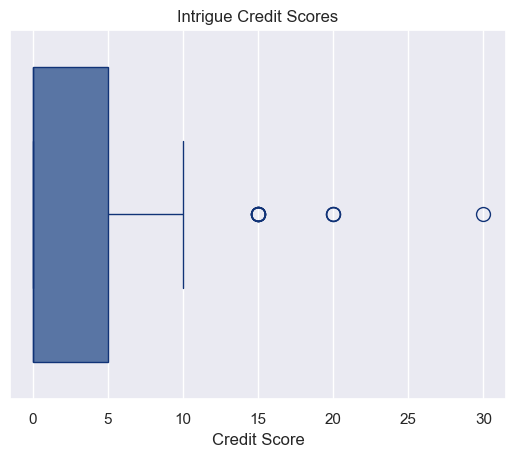

In [7]:
sns.set_theme()

sns.boxplot(
    data=df,
    x="Credit Score",
    linecolor="#137",
    linewidth=1,
    # fill=False,
    flierprops={"marker": "o"},
    fliersize=10,
    orient="h",
).set(title='Intrigue Credit Scores')

In [11]:
from neighborly import inspection

inspection.inspect(sim, 380)

|| Madison Sayer(380) ||

Active: True
Name: Madison Sayer(380)

=== Character ===

Name: 'Madison Sayer'
Age: 45 (ADULT)
Sex: FEMALE
Species: 'Human'
Resident of: 'Galestown(1)'

=== Stats ===

Stat                Base Value[boost]    Min    Max
------------------  -------------------  -----  ------
Lifespan            72[+0]               0      999999
Fertility           46[+9]               0      100
Diplomacy           35[-10]              0      100
Martial             15[+0]               0      100
Stewardship         56[+0]               0      100
Intrigue            18[-10]              0      100
Learning            7[+0]                0      100
Prowess             26[+0]               0      100
Boldness            77[-20]              0      100
Compassion          8[+0]                0      100
Greed               45[+0]               0      100
Honor               17[+0]               0      100
Rationality         22[+0]               0      100
Sociability        

In [12]:
from neighborly.components.shared import Modifiers

character = sim.world.gameobjects.get_gameobject(380)

print(character.get_component(StoryCreditScore).stat.value)

print(character.get_component(StoryCreditScore).stat._modifiers)

modifiers = character.get_component(Modifiers)

# for m in modifiers.modifiers:
#     if isinstance(m, StatModifier)

30.0
[<neighborly.plugins.modifiers.StatModifier object at 0x13bf465c0>, <neighborly.plugins.modifiers.StatModifier object at 0x13bf46920>, <neighborly.plugins.modifiers.StatModifier object at 0x13bf74100>, <neighborly.plugins.modifiers.StatModifier object at 0x13bf76560>, <neighborly.plugins.modifiers.StatModifier object at 0x13bfb88e0>, <neighborly.plugins.modifiers.StatModifier object at 0x13bfba620>]
